In [3]:
print(R.version.string)

[1] "R version 4.5.2 (2025-10-31 ucrt)"


In [24]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("corHMM")
})

In [20]:
STATES <- read.csv("../../data/chapter2/FREDv3subset/finalized_states_395_species.csv", stringsAsFactors = TRUE)[, c("binominal", "state")] # finalized mycorrhizal states
COLLAB_AXIS <- read.csv("../../data/chapter2/FREDv3subset/collab_ord1_species_avgs_SRL_RD.csv", stringsAsFactors = TRUE) # first order species averaged RD and SRL values
MERGED <- merge(x = STATES, y = COLLAB_AXIS, by = "binominal")
stopifnot(nrow(MERGED)==395)

COLLAB_395SP_TREE <- ape::multi2di(ape::read.tree("../../data/chapter2/uphylomaker/FRED_subset_collab_395sp.tre")) # phylogenetic tree created for the 395 species using U.PhyloMaker
stopifnot(length(COLLAB_395SP_TREE$tip.label)==395)

# MERGED contains '/' in the binominal names
data <- data.frame(binominal = gsub(MERGED$binominal, pattern = ' ', replacement = '_'), RD = MERGED$F00679, SRL = MERGED$F00727, myco = gsub(x = MERGED$state, pattern = '/', replacement = ''))
matched_row_indices <- match(COLLAB_395SP_TREE$tip.label, data$binominal)
stopifnot(all(data$binominal[matched_row_indices] == COLLAB_395SP_TREE$tip.label))

data <- data[matched_row_indices, ] # reorder the dataset to match the species order in the phylogeny
stopifnot(all(data$binominal == COLLAB_395SP_TREE$tip.label))
stopifnot(length(unique(data$binominal)) == length(data$binominal))

In [21]:
RD <- setNames(object = data$RD, nm = data$binominal)
SRL <- setNames(object = data$SRL, nm = data$binominal)
STATES <- setNames(object = data$myco, nm = data$binominal)

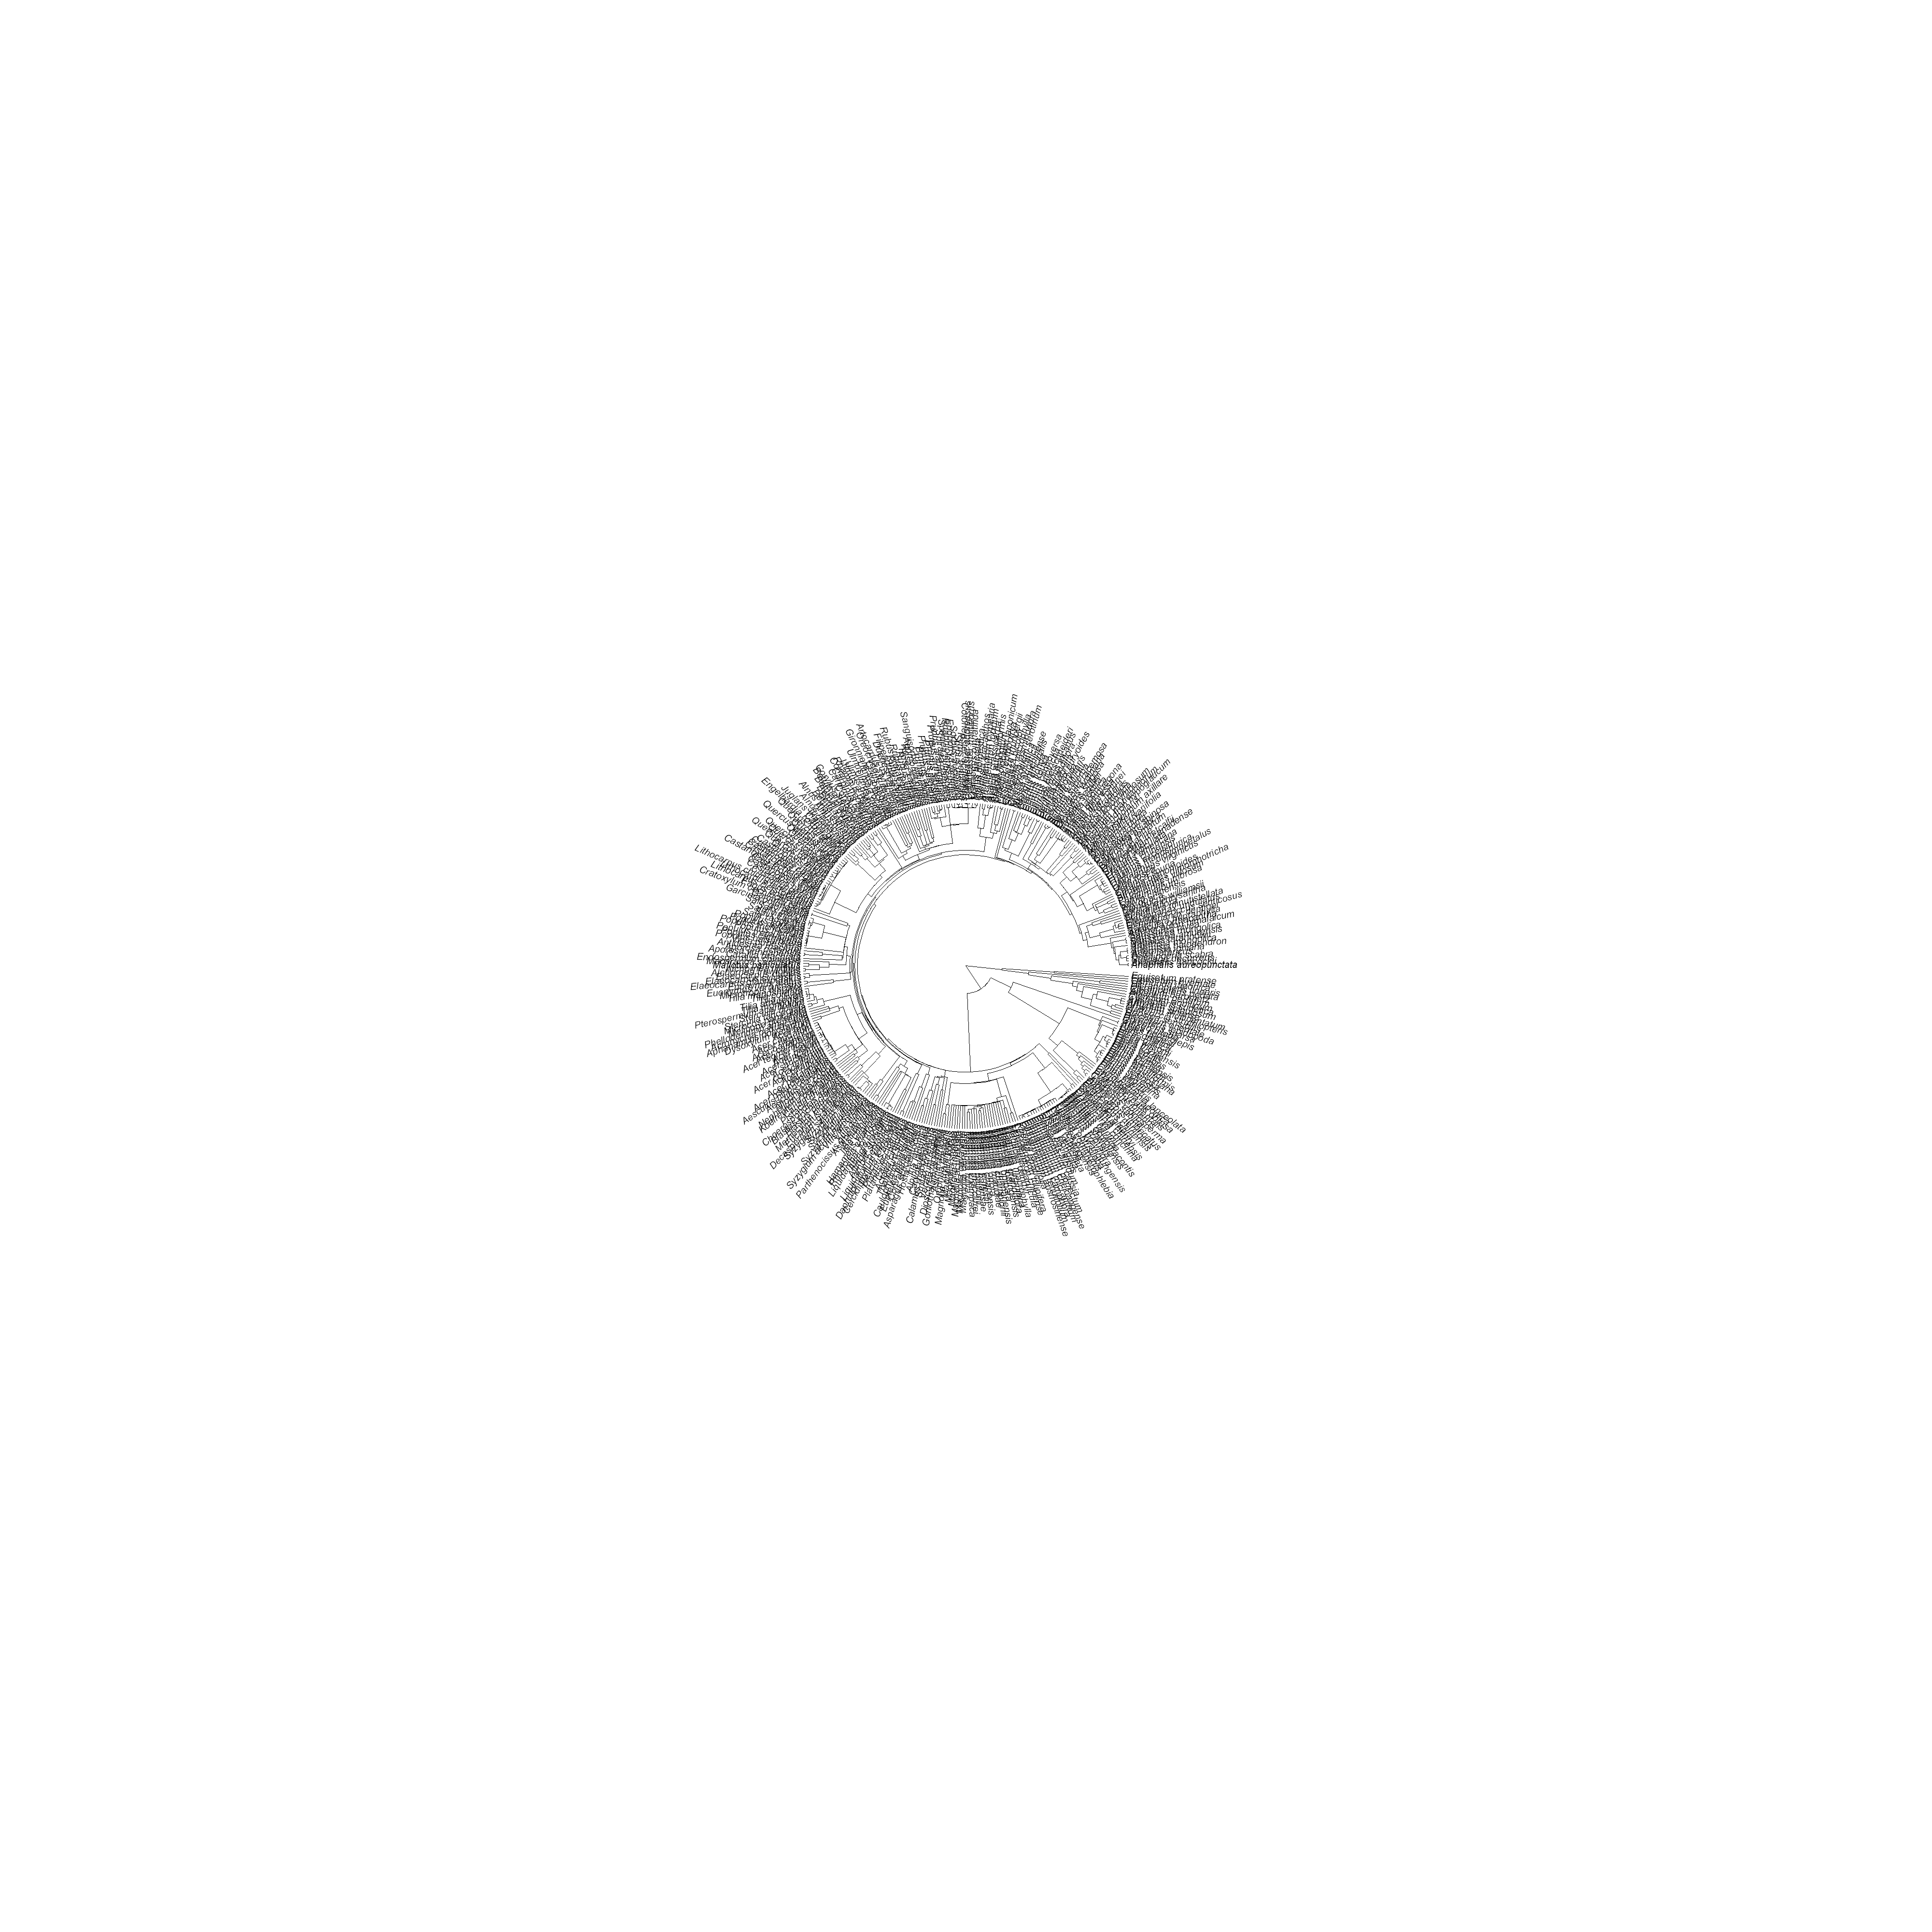

In [39]:
# visualize the node numbers in the phylogeny

options(repr.plot.width = 40, repr.plot.height = 40)

phytools::plotTree(tree = COLLAB_395SP_TREE, ftype = "i", fsize = 1.2, type = "fan", lwd = 1, part = 0.99)

In [22]:
phytools::rerootingMethod(tree = COLLAB_395SP_TREE, x = STATES, model = "ER") # ACE of mycorrhizal states using the re rooting method


Note:
   This function is redundant with 'phytools::ancr' in situations in
   which it should be used (symmetric Q matrices) & invalid for non-
   symmetric Q matrices (e.g., model='ARD').



Ancestral character estimates using re-rooting method
of Yang et al. (1995):
          AM    AMEcM     AMNM      EcM      ErM       NM
396 0.989595 0.001035 0.003598 0.001108 0.001035 0.003629
397 0.999094 0.000097 0.000251 0.000209 0.000097 0.000253
398 1.000000 0.000000 0.000000 0.000000 0.000000 0.000000
399 1.000000 0.000000 0.000000 0.000000 0.000000 0.000000
400 1.000000 0.000000 0.000000 0.000000 0.000000 0.000000
401 1.000000 0.000000 0.000000 0.000000 0.000000 0.000000
402 1.000000 0.000000 0.000000 0.000000 0.000000 0.000000
403 0.999990 0.000000 0.000000 0.000000 0.000000 0.000008
404 0.999999 0.000000 0.000000 0.000000 0.000000 0.000001
405 1.000000 0.000000 0.000000 0.000000 0.000000 0.000000
406 1.000000 0.000000 0.000000 0.000000 0.000000 0.000000
407 1.000000 0.000000 0.000000 0.000000 0.000000 0.000000
408 1.000000 0.000000 0.000000 0.000000 0.000000 0.000000
409 1.000000 0.000000 0.000000 0.000000 0.000000 0.000000
410 0.999999 0.000000 0.000000 0.000000 0.000000 0.00

In [31]:
# ACE of mycorrhizal states using corHMM (MARGINAL ACE)
corHMM::corHMM(phy = COLLAB_395SP_TREE, data = data[, c("binominal", "myco")], model = "ER", node.states = "marginal", rate.cat = 1)

You specified 'fixed.nodes=FALSE' but included a phy object with node labels. These node labels have been removed.


Warning message in corHMM::corHMM(phy = COLLAB_395SP_TREE, data = data[, c("binominal", :
"Branch lengths of 0 detected. Adding 1e-5 to these branches."


State distribution in data:
States:	1	2	3	4	5	6	
Counts:	300	15	8	65	3	4	
Beginning thorough optimization search -- performing 0 random restarts 
Finished. Inferring ancestral states using marginal reconstruction. 



Fit
      -lnL      AIC     AICc Rate.cat ntax
 -142.3041 286.6082 286.6183        1  395

Legend
      1       2       3       4       5       6 
   "AM" "AMEcM"  "AMNM"   "EcM"   "ErM"    "NM" 

Rates
             (1,R1)       (2,R1)       (3,R1)       (4,R1)       (5,R1)
(1,R1)           NA 0.0002729775 0.0002729775 0.0002729775 0.0002729775
(2,R1) 0.0002729775           NA 0.0002729775 0.0002729775 0.0002729775
(3,R1) 0.0002729775 0.0002729775           NA 0.0002729775 0.0002729775
(4,R1) 0.0002729775 0.0002729775 0.0002729775           NA 0.0002729775
(5,R1) 0.0002729775 0.0002729775 0.0002729775 0.0002729775           NA
(6,R1) 0.0002729775 0.0002729775 0.0002729775 0.0002729775 0.0002729775
             (6,R1)
(1,R1) 0.0002729775
(2,R1) 0.0002729775
(3,R1) 0.0002729775
(4,R1) 0.0002729775
(5,R1) 0.0002729775
(6,R1)           NA

Arrived at a reliable solution 